# Context Engineering: 4 Strategies, One Agent, 30 Turns

Every LLM call packs three things into the context window: **instructions**, **knowledge**, and **tool results**. Each turn re-sends everything before it.

This experiment benchmarks 4 context management strategies on a 30-turn task about a fictional framework **AgentForge**.

| # | Strategy | What it does |
|---|----------|---------------|
| 1 | Baseline | Drop oldest messages when over token budget |
| 2 | Sliding window | Keep last N messages |
| 3 | Running summary | Compress old messages into rolling summary |
| 4 | Scratchpad | Save facts externally, inject all into system message |

In [18]:
import os, json, statistics, time, re, getpass
from typing import TypedDict, Annotated

import pandas as pd
from langchain_core.messages import (
    HumanMessage, SystemMessage, AIMessage,
    RemoveMessage, AnyMessage, ToolMessage,
)
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.checkpoint.memory import InMemorySaver

from helpers import (
    score_answer, INPUT_COST, OUTPUT_COST,
    plot_token_growth, plot_phase_accuracy,
    plot_accuracy_heatmap, plot_tradeoff_scatter,
    plot_cumulative_cost, plot_radar,
)

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f'{var}: ')

_set_env('GOOGLE_API_KEY')

In [19]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)

TOKEN_WINDOW = 1_400
TRIGGER_PCT  = 0.80
WINDOW_SIZE  = 12
N_RUNS       = 5
RESULTS_DIR  = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

In [20]:
TURNS = [
    # Phase 1: Fact injection (T1-T10)
    {"id": 1, "question": "FACT (Turn 1): The AgentForge repository is written in Go 78.2% and Rust 21.8%. It has 4,312 stars and 1,847 commits on main. Acknowledge this fact.",
     "ground_truth": "78.2", "type": "str", "depends_on": []},
    {"id": 2, "question": "FACT (Turn 2): All AgentForge agents inherit from CoreAgent, which requires implementing `func (a *Agent) Execute(ctx RunContext) ([]Signal, error)`. Acknowledge this fact.",
     "ground_truth": "CoreAgent", "type": "str", "depends_on": []},
    {"id": 3, "question": "FACT (Turn 3): AgentForge has three workflow agent types beyond TaskAgent: PipelineAgent (strict order), SwarmAgent (concurrent with ctx.Fork), and CycleAgent (loops until Halt=true). Acknowledge this fact.",
     "ground_truth": "PipelineAgent", "type": "str", "depends_on": []},
    {"id": 4, "question": "FACT (Turn 4): BridgeCapability enables agent-to-agent delegation. FuncCapability wraps Go functions as capabilities \u2014 doc comments become descriptions, typed params generate schema. Acknowledge this fact.",
     "ground_truth": "BridgeCapability", "type": "str", "depends_on": []},
    {"id": 5, "question": "FACT (Turn 5): AgentForge supports three session store backends: MemoryStore (in-memory, default), BoltStore (persistent via BoltDB, requires bbolt>=1.4), and CloudSpannerStore (Google Cloud managed). Acknowledge this fact.",
     "ground_truth": "MemoryStore", "type": "str", "depends_on": []},
    {"id": 6, "question": "FACT (Turn 6): Third-party models use BridgeLLM adapter: bridgellm.New('openai/gpt-4o') or bridgellm.New('anthropic/claude-3-haiku'). Native Forge models need no adapter: WithModel('forge-7b-fast'). Acknowledge this fact.",
     "ground_truth": "BridgeLLM", "type": "str", "depends_on": []},
    {"id": 7, "question": "FACT (Turn 7): The Conductor class orchestrates agent execution with session management. It uses RunAsync to return a channel of Signals. A Signal has Author, Content, and Flags fields. IsFinalResponse() checks completion. Acknowledge this fact.",
     "ground_truth": "Conductor", "type": "str", "depends_on": []},
    {"id": 8, "question": "FACT (Turn 8): Setting OutputSpec on a TaskAgent disables both capability use and delegation. OutputSpec defines a Protobuf schema for structured output. OutputSlot stores the final response text in the session Vault. Acknowledge this fact.",
     "ground_truth": "OutputSpec", "type": "str", "depends_on": []},
    {"id": 9, "question": "FACT (Turn 9): Agent communication uses three mechanisms: shared session Vault (ctx.Session.Vault as map[string]any), model-driven handoff via RouteToAgent resolved by AutoRouter, and Hooks (before/after model calls). Acknowledge this fact.",
     "ground_truth": "Vault", "type": "str", "depends_on": []},
    {"id": 10, "question": "FACT (Turn 10): TaskAgent directives support template syntax {{var}} and {{state.var}} for variable interpolation. Null-safe access uses {{var?}}. TuningConfig controls Temperature, MaxTokens, NucleusP, and BeamK. Acknowledge this fact.",
     "ground_truth": "{{var}}", "type": "str", "depends_on": []},

    # Phase 2: Recent-fact questions (T11-T16) — still in sliding window
    {"id": 11, "question": "Based on the fact from Turn 10, what is the null-safe template syntax for variable access?",
     "ground_truth": "{{var?}}", "type": "str", "depends_on": [10]},
    {"id": 12, "question": "Based on the fact from Turn 9, name the three agent communication mechanisms.",
     "ground_truth": "Vault", "type": "str", "depends_on": [9]},
    {"id": 13, "question": "Based on the fact from Turn 8, what two capabilities are disabled when OutputSpec is set?",
     "ground_truth": "disables", "type": "str", "depends_on": [8]},
    {"id": 14, "question": "Based on the fact from Turn 7, what method on a Signal checks whether an agent response is complete?",
     "ground_truth": "IsFinalResponse", "type": "str", "depends_on": [7]},
    {"id": 15, "question": "Using facts from Turn 8 and Turn 9: If OutputSpec disables delegation, can an agent with OutputSpec still use RouteToAgent handoff?",
     "ground_truth": "cannot", "type": "str", "depends_on": [8, 9]},
    {"id": 16, "question": "Using facts from Turn 7 and Turn 10: How would you configure a Conductor with TuningConfig Temperature=0.2?",
     "ground_truth": "Temperature", "type": "str", "depends_on": [7, 10]},

    # Phase 3: Mid-fact questions (T17-T23) — outside sliding window
    {"id": 17, "question": "Based on the fact from Turn 3, what happens when a CycleAgent delegate yields Halt=true?",
     "ground_truth": "stop", "type": "str", "depends_on": [3]},
    {"id": 18, "question": "Based on the fact from Turn 5, what external dependency does BoltStore require?",
     "ground_truth": "bbolt", "type": "str", "depends_on": [5]},
    {"id": 19, "question": "Based on the fact from Turn 4, how does FuncCapability generate a capability description?",
     "ground_truth": "doc comment", "type": "str", "depends_on": [4]},
    {"id": 20, "question": "Based on the fact from Turn 6, how would you configure an agent to use Claude 3 Haiku?",
     "ground_truth": "bridgellm", "type": "str", "depends_on": [6]},
    {"id": 21, "question": "Using facts from Turn 4 and Turn 8: Can you combine BridgeCapability delegation with OutputSpec on the same agent?",
     "ground_truth": "cannot", "type": "str", "depends_on": [4, 8]},
    {"id": 22, "question": "Using facts from Turn 3 and Turn 9: When SwarmAgent runs delegates concurrently via ctx.Fork, do forked children share the same session Vault?",
     "ground_truth": "shared", "type": "str", "depends_on": [3, 9]},
    {"id": 23, "question": "Using facts from Turn 5 and Turn 7: What does BoltStore require that MemoryStore does not, and how does the Conductor use session stores?",
     "ground_truth": "bbolt", "type": "str", "depends_on": [5, 7]},

    # Phase 4: Deep recall (T24-T30) — earliest facts, long gone
    {"id": 24, "question": "Recall test: What was the exact fact from Turn 1? Give the language percentages and repo stats.",
     "ground_truth": "78.2", "type": "str", "depends_on": [1]},
    {"id": 25, "question": "Recall test: What was the exact fact from Turn 2? Name the base class and its method signature.",
     "ground_truth": "CoreAgent", "type": "str", "depends_on": [2]},
    {"id": 26, "question": "Recall test: What was the exact fact from Turn 4? Name both capability classes.",
     "ground_truth": "BridgeCapability", "type": "str", "depends_on": [4]},
    {"id": 27, "question": "Recall test: What was the exact fact from Turn 5? Name all three session store backends.",
     "ground_truth": "CloudSpannerStore", "type": "str", "depends_on": [5]},
    {"id": 28, "question": "Using facts from Turn 1, Turn 2, and Turn 6: What is the repo language split, what base class do agents inherit from, and what adapter enables third-party models?",
     "ground_truth": "BridgeLLM", "type": "str", "depends_on": [1, 2, 6]},
    {"id": 29, "question": "Recall test: What were the facts from Turn 3 and Turn 6? Name the three workflow agents and the model adapter.",
     "ground_truth": "CycleAgent", "type": "str", "depends_on": [3, 6]},
    {"id": 30, "question": "Final recall: Summarize facts from Turn 1 (percentages), Turn 3 (workflow agents), Turn 5 (session stores), and Turn 9 (communication mechanisms).",
     "ground_truth": "PipelineAgent", "type": "str", "depends_on": [1, 3, 5, 9]},
]
print(f"{len(TURNS)} turns across 4 phases")

30 turns across 4 phases


In [21]:
SYS_MSG = """You are a research assistant. You will be given facts about a fictional framework called AgentForge. Memorize each fact carefully. Later you will be quizzed.

IMPORTANT: AgentForge is entirely fictional. All answers MUST come from facts stated in this conversation.

Rules:
- When acknowledging a fact, repeat key details (names, numbers, percentages) exactly.
- When answering, reference specific conversation facts.
- If a fact is not in your current context, say "I don't have that information in my current context."
- Be precise: exact class names, exact numbers, exact percentages.
"""

SYS_MSG_SCRATCHPAD = SYS_MSG + """
CRITICAL: You MUST call write_scratchpad after EVERY turn to save key findings.

Workflow: 1) Read fact/question  2) Answer  3) call write_scratchpad(key="turn_N_topic", value="exact details")
"""

@tool
def write_scratchpad(key: str, value: str) -> str:
    """Save a finding to your scratchpad for later reference."""
    return f"SCRATCHPAD_WRITE::{key}::{value}"

@tool
def read_scratchpad() -> str:
    """Read your current scratchpad (injected by context manager each turn)."""
    return "Scratchpad contents are injected at the start of each turn."

TOOLS = [write_scratchpad, read_scratchpad]
TOOL_MAP = {t.name: t for t in TOOLS}

print(f"SYS_MSG: ~{len(SYS_MSG)//4} tokens | SYS_MSG_SCRATCHPAD: ~{len(SYS_MSG_SCRATCHPAD)//4} tokens")

SYS_MSG: ~147 tokens | SYS_MSG_SCRATCHPAD: ~195 tokens


In [22]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    summary: str
    scratchpad: str
    sys_msg: str


def token_count(messages):
    """Approximate token count. ~1 token per 3 chars (calibrated to match API counts)."""
    return sum(
        len(m.content) // 3
        for m in messages
        if hasattr(m, 'content') and isinstance(m.content, str)
    )


def budget(state):
    """Token budget for conversation messages = total window minus system message."""
    sys = state.get("sys_msg") or SYS_MSG
    return TOKEN_WINDOW - len(sys) // 3

In [23]:
# ── Strategy 1: Baseline ── drop oldest messages until under budget
def baseline(state: State) -> dict:
    msgs = list(state["messages"])
    limit = budget(state)
    removed = []
    while token_count(msgs) > limit and len(msgs) > 1:
        removed.append(RemoveMessage(id=msgs.pop(0).id))
    return {"messages": removed} if removed else {}


# ── Strategy 2: Sliding window ── keep last WINDOW_SIZE messages
def sliding_window(state: State) -> dict:
    msgs = state["messages"]
    limit = budget(state)
    if len(msgs) <= WINDOW_SIZE and token_count(msgs) <= limit:
        return {}
    keep = msgs[-WINDOW_SIZE:]
    while token_count(keep) > limit and len(keep) > 1:
        keep.pop(0)
    trim = [m for m in msgs if m not in keep]
    return {"messages": [RemoveMessage(id=m.id) for m in trim if m.id]}


# ── Strategy 3: Running summary ── compress old messages into rolling summary
def running_summary(state: State) -> dict:
    msgs = state["messages"]
    keep_n = 8
    limit = budget(state)
    if len(msgs) <= keep_n + 2 and token_count(msgs) / limit <= TRIGGER_PCT:
        return {}

    old, recent = msgs[:-keep_n], msgs[-keep_n:]
    old_text = "\n".join(
        f"{type(m).__name__}: {m.content[:500]}"
        for m in old if hasattr(m, 'content') and isinstance(m.content, str)
    )
    max_tok = max(limit - token_count(recent) - 50, 100)
    prev = state.get('summary', '')

    result = llm.invoke([HumanMessage(content=(
        f"You are maintaining a rolling knowledge base. Merge the prior summary with the new messages below.\n\n"
        f"Rules:\n"
        f"- ALWAYS prefix each bullet with its Turn number: 'T1: ...', 'T3: ...'\n"
        f"- Keep exact names, numbers, percentages (e.g. Go 78.2%, CoreAgent, bbolt>=1.4)\n"
        f"- One bullet per fact, max 20 words each\n"
        f"- If a fact appears in both prior summary and new messages, keep the more detailed version\n"
        f"- MAX {max_tok} tokens total\n\n"
        f"Prior summary:\n{prev}\n\n"
        f"New messages:\n{old_text}"
    ))])
    removals = [RemoveMessage(id=m.id) for m in old if m.id]
    summary_msg = HumanMessage(content=f"[CONTEXT SUMMARY]\n{result.content}")
    return {"messages": removals + [summary_msg], "summary": result.content}


# ── Strategy 4: Scratchpad ── externalize facts, sliding window trim
def scratchpad_manager(state: State) -> dict:
    msgs = state["messages"]
    pad = state.get("scratchpad", "")
    out = {}

    # Harvest new scratchpad writes from tool results
    for m in msgs:
        c = m.content if hasattr(m, 'content') and isinstance(m.content, str) else ""
        if "SCRATCHPAD_WRITE::" in c:
            parts = c.split("::", 2)
            if len(parts) == 3:
                entry = f"{parts[1].strip()}: {parts[2].strip()}"
                if entry not in pad:
                    pad += f"{entry}\n"
    if pad:
        out["scratchpad"] = pad
        out["sys_msg"] = SYS_MSG_SCRATCHPAD + f"\n\nYour scratchpad:\n{pad}"

    # Trim with headroom reserved for tool loop messages
    limit = budget({**state, **out})
    if len(msgs) > WINDOW_SIZE or token_count(msgs) / max(limit, 1) > TRIGGER_PCT:
        groups, cur = [], []
        for m in msgs:
            if isinstance(m, HumanMessage) and cur:
                groups.append(cur); cur = [m]
            else:
                cur.append(m)
        if cur:
            groups.append(cur)

        kept, n = [], 0
        for g in reversed(groups):
            candidate_msgs = [m for g2 in ([g] + kept) for m in g2]
            if (n + len(g) > WINDOW_SIZE or token_count(candidate_msgs) > limit) and n > 0:
                break
            kept.insert(0, g); n += len(g)

        kept_ids = {id(m) for g in kept for m in g}
        trim = [m for m in msgs if id(m) not in kept_ids]
        if trim:
            out["messages"] = [RemoveMessage(id=m.id) for m in trim if m.id]

    return out





STRATEGIES = {
    "baseline": baseline,
    "sliding_window": sliding_window,
    "running_summary": running_summary,
    "scratchpad": scratchpad_manager,
}

In [24]:
def call_llm(state: State) -> dict:
    msgs = [SystemMessage(content=state.get("sys_msg") or SYS_MSG)] + state["messages"]
    return {"messages": [llm.invoke(msgs)]}


def call_llm_tools(state: State) -> dict:
    sys = state.get("sys_msg") or SYS_MSG_SCRATCHPAD
    bound = llm.bind_tools(TOOLS)
    base = [SystemMessage(content=sys)] + state["messages"]
    new = []
    for _ in range(5):
        resp = bound.invoke(base + new)
        new.append(resp)
        if not resp.tool_calls:
            break
        for tc in resp.tool_calls:
            fn = TOOL_MAP.get(tc["name"])
            if fn:
                new.append(ToolMessage(content=str(fn.invoke(tc["args"])), tool_call_id=tc["id"]))
    return {"messages": new}


def build_graph(strategy: str):
    g = StateGraph(State)
    g.add_node("manage", STRATEGIES[strategy])
    g.add_node("llm", call_llm_tools if strategy == "scratchpad" else call_llm)
    g.add_edge(START, "manage")
    g.add_edge("manage", "llm")
    g.add_edge("llm", END)
    return g.compile(checkpointer=InMemorySaver())

In [25]:
def run_experiment(strategy, n_runs=N_RUNS):
    sys_msg = SYS_MSG_SCRATCHPAD if strategy == "scratchpad" else SYS_MSG
    print(f"\n{'='*50}\n {strategy} ({n_runs} runs x {len(TURNS)} turns)\n{'='*50}")

    all_runs = []
    for r in range(n_runs):
        print(f"\n--- run {r+1}/{n_runs} ---")
        graph = build_graph(strategy)
        cfg = {"configurable": {"thread_id": f"{strategy}_{r}_{int(time.time())}"}}
        turns, seen = [], set()

        for t in TURNS:
            t0 = time.time()
            try:
                res = graph.invoke(
                    {"messages": [HumanMessage(content=t["question"])], "sys_msg": sys_msg},
                    cfg,
                    version="v2",
                )
                state = res.value

                # Extract last AI answer (skip tool-call-only messages)
                answer = None
                for m in reversed(state["messages"]):
                    if isinstance(m, AIMessage) and m.content and not getattr(m, 'tool_calls', None):
                        answer = m.content if isinstance(m.content, str) else " ".join(
                            b.get("text", "") if isinstance(b, dict) else str(b) for b in m.content)
                        break

                sc = score_answer(answer, t["ground_truth"], t["type"])

                # Token tracking: peak (max single call) for budget, sum for cost
                peak_in = total_in = total_out = 0
                for m in state["messages"]:
                    if isinstance(m, AIMessage) and getattr(m, "usage_metadata", None):
                        mid = getattr(m, 'id', id(m))
                        if mid not in seen:
                            seen.add(mid)
                            inp = m.usage_metadata.get("input_tokens", 0)
                            peak_in = max(peak_in, inp)
                            total_in += inp
                            total_out += m.usage_metadata.get("output_tokens", 0)

                # Approximate managed context = peak API tokens (what LLM actually saw)
                turns.append({
                    "turn": t["id"], "score": sc,
                    "input_tokens": peak_in, "output_tokens": total_out,
                    "api_input_tokens": total_in,
                    "answer": (answer or "")[:500], "ground_truth": t["ground_truth"],
                    "answer_type": t["type"], "depends_on": t["depends_on"],
                    "question": t["question"], "duration_s": round(time.time() - t0, 2),
                    "snapshot": {"total_tokens_in_context": peak_in},
                })
                print(f"  T{t['id']:2d} {'\u2713' if sc >= 0.5 else '\u2717'} {sc:.1f}  {peak_in:>5d} tok")

            except Exception as e:
                print(f"  T{t['id']:2d} CRASHED: {e}")
                turns.append({
                    "turn": t["id"], "score": 0.0,
                    "input_tokens": 0, "api_input_tokens": 0, "output_tokens": 0,
                    "ground_truth": t["ground_truth"], "answer_type": t["type"],
                    "depends_on": t["depends_on"], "question": t["question"],
                    "duration_s": round(time.time() - t0, 2), "error": str(e),
                })

        scores = [x["score"] for x in turns]
        run = {
            "run": r + 1, "strategy": strategy, "turns": turns,
            "total_input_tokens": sum(x["api_input_tokens"] for x in turns),
            "total_output_tokens": sum(x["output_tokens"] for x in turns),
            "total_cost": sum(x["api_input_tokens"] * INPUT_COST + x["output_tokens"] * OUTPUT_COST for x in turns),
            "mean_score": statistics.mean(scores),
            "retention_score": scores[-1],
            "phase_scores": {
                "fact_injection": statistics.mean(scores[0:10]),
                "single_dep": statistics.mean(scores[10:16]),
                "multi_dep": statistics.mean(scores[16:23]),
                "recall": statistics.mean(scores[23:30]),
            },
        }
        all_runs.append(run)
        print(f"  => acc={run['mean_score']:.2f}  retention={run['retention_score']:.2f}  cost=${run['total_cost']:.4f}")

    return all_runs

## Run Experiments

In [26]:
baseline_runs = run_experiment("baseline")
sliding_runs = run_experiment("sliding_window")
summary_runs = run_experiment("running_summary")
scratchpad_runs = run_experiment("scratchpad")


 baseline (5 runs x 30 turns)

--- run 1/5 ---
  T 1 ✓ 1.0    181 tok
  T 2 ✓ 1.0    271 tok
  T 3 ✓ 1.0    357 tok
  T 4 ✓ 1.0    439 tok
  T 5 ✓ 1.0    530 tok
  T 6 ✓ 1.0    651 tok
  T 7 ✓ 1.0    784 tok
  T 8 ✓ 1.0    892 tok
  T 9 ✓ 1.0    999 tok
  T10 ✓ 1.0    968 tok
  T11 ✓ 1.0    969 tok
  T12 ✓ 1.0    972 tok
  T13 ✗ 0.0    987 tok
  T14 ✓ 1.0    989 tok
  T15 ✗ 0.0   1001 tok
  T16 ✓ 1.0    961 tok
  T17 ✗ 0.0    944 tok
  T18 ✗ 0.0    975 tok
  T19 ✗ 0.0    957 tok
  T20 ✗ 0.0    994 tok
  T21 ✗ 0.0    984 tok
  T22 ✓ 1.0    973 tok
  T23 ✗ 0.0   1000 tok
  T24 ✗ 0.0    971 tok
  T25 ✗ 0.0   1007 tok
  T26 ✗ 0.0   1016 tok
  T27 ✗ 0.0   1007 tok
  T28 ✗ 0.0    992 tok
  T29 ✗ 0.0   1010 tok
  T30 ✗ 0.0    999 tok
  => acc=0.50  retention=0.00  cost=$0.0031

--- run 2/5 ---
  T 1 ✓ 1.0    181 tok
  T 2 ✓ 1.0    271 tok
  T 3 ✓ 1.0    357 tok
  T 4 ✓ 1.0    439 tok
  T 5 ✓ 1.0    530 tok
  T 6 ✓ 1.0    651 tok
  T 7 ✓ 1.0    784 tok
  T 8 ✓ 1.0    892 tok
  T 9 ✓ 1.0    99

In [27]:
strategies = {
    "baseline": baseline_runs,
    "sliding_window": sliding_runs,
    "running_summary": summary_runs,
    "scratchpad": scratchpad_runs,
}

rows = []
for name, runs in strategies.items():
    avg = lambda k: statistics.mean([r[k] for r in runs])
    phases = {k: statistics.mean([r["phase_scores"][k] for r in runs]) for k in runs[0]["phase_scores"]}
    rows.append({
        "Strategy": name,
        "Accuracy": f"{avg('mean_score'):.2f}",
        "Retention": f"{avg('retention_score'):.2f}",
        "Tokens": f"{avg('total_input_tokens'):,.0f}",
        "Cost": f"${avg('total_cost'):.4f}",
        "P1 (Facts)": f"{phases['fact_injection']:.2f}",
        "P2 (Recent)": f"{phases['single_dep']:.2f}",
        "P3 (Mid)": f"{phases['multi_dep']:.2f}",
        "P4 (Recall)": f"{phases['recall']:.2f}",
    })
pd.DataFrame(rows)

,Strategy,Accuracy,Retention,Tokens,Cost,P1 (Facts),P2 (Recent),P3 (Mid),P4 (Recall)
0,baseline,0.50,0.00,"25,780",$0.0031,1.00,0.67,0.14,0.00
1,sliding_window,0.47,0.00,"17,686",$0.0024,1.00,0.50,0.00,0.14
2,running_summary,0.73,1.00,"28,943",$0.0035,1.00,0.67,0.43,0.71
3,scratchpad,1.00,1.00,"83,179",$0.0101,1.00,1.00,1.00,1.00


In [28]:
output_path = os.path.join(RESULTS_DIR, "context_engineering.json")
with open(output_path, "w") as f:
    json.dump({
        "experiment": "context_engineering",
        "model": "gemini-2.5-flash-lite",
        "config": {"token_window": TOKEN_WINDOW, "trigger_pct": TRIGGER_PCT, "window_size": WINDOW_SIZE, "n_runs": N_RUNS},
        "strategies": {k: {"runs": v} for k, v in strategies.items()},
    }, f, indent=2, default=str)
print(f"Saved to {output_path}")

Saved to results/context_engineering.json


## Plots

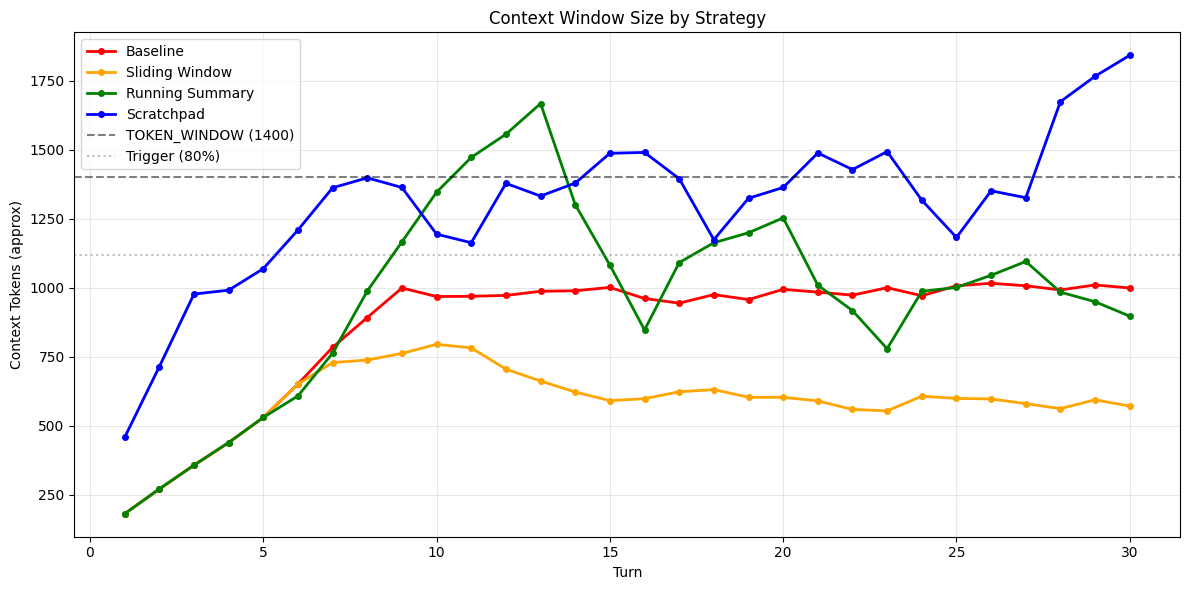

In [29]:
plot_token_growth(strategies, len(TURNS), TOKEN_WINDOW, TRIGGER_PCT)

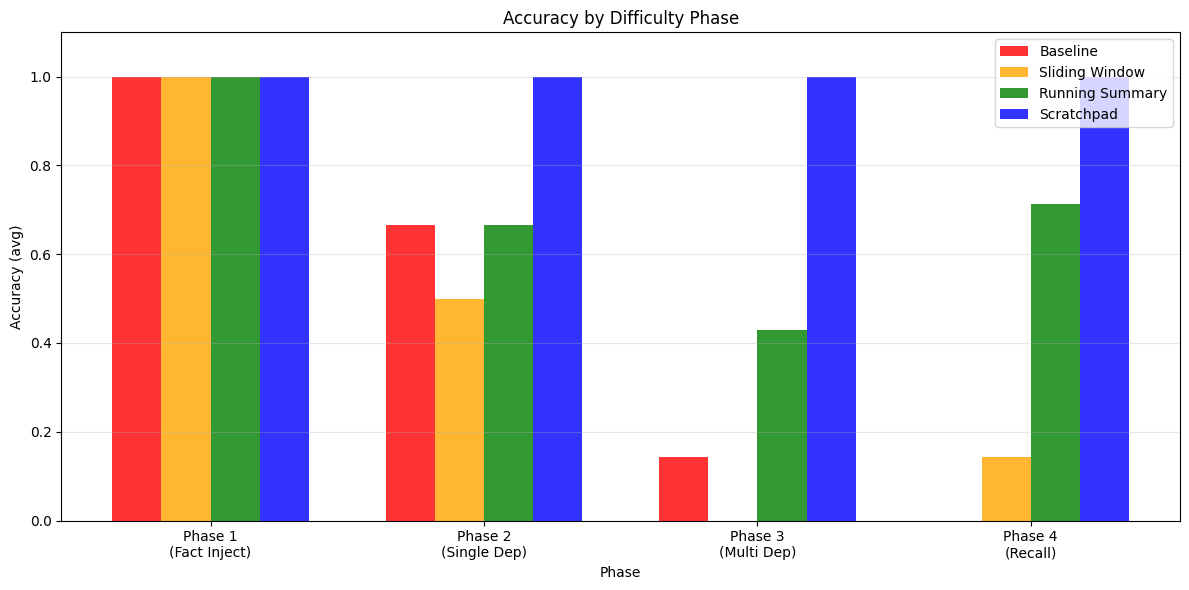

In [30]:
plot_phase_accuracy(strategies)

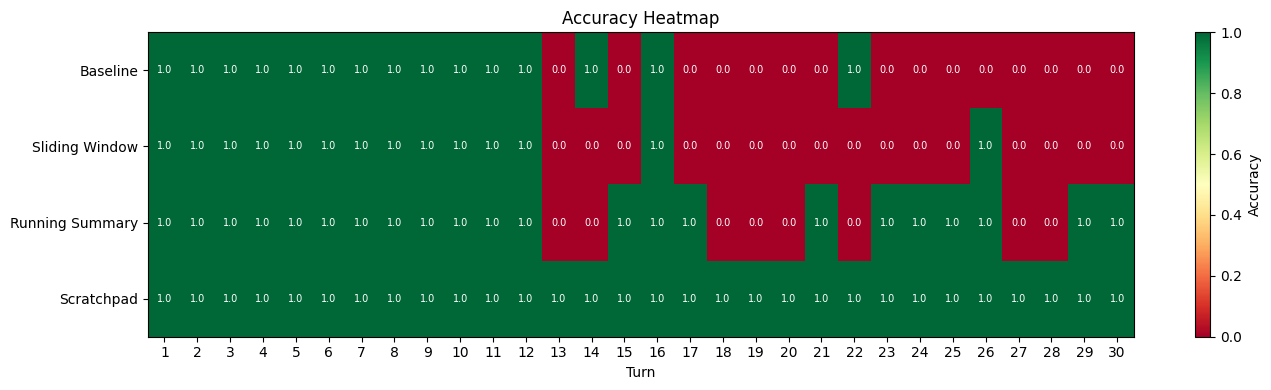

In [31]:
plot_accuracy_heatmap(strategies, len(TURNS))

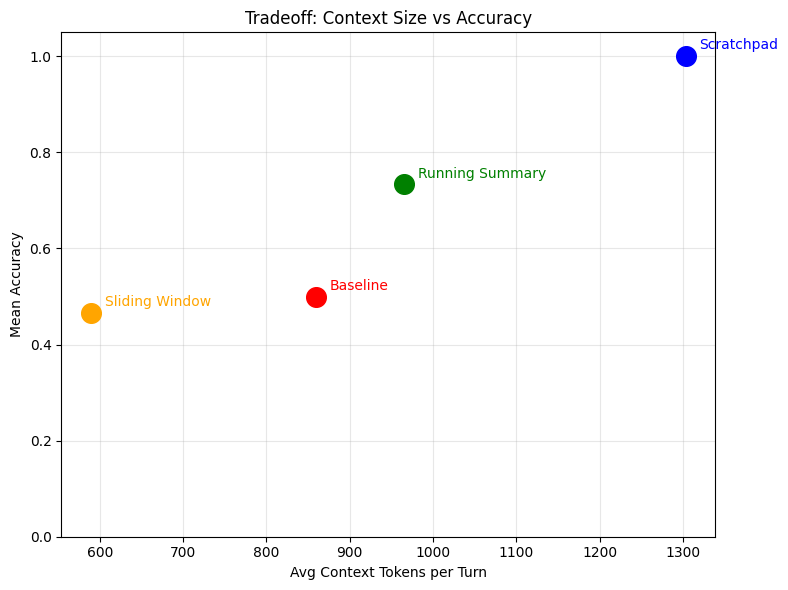

In [32]:
plot_tradeoff_scatter(strategies)

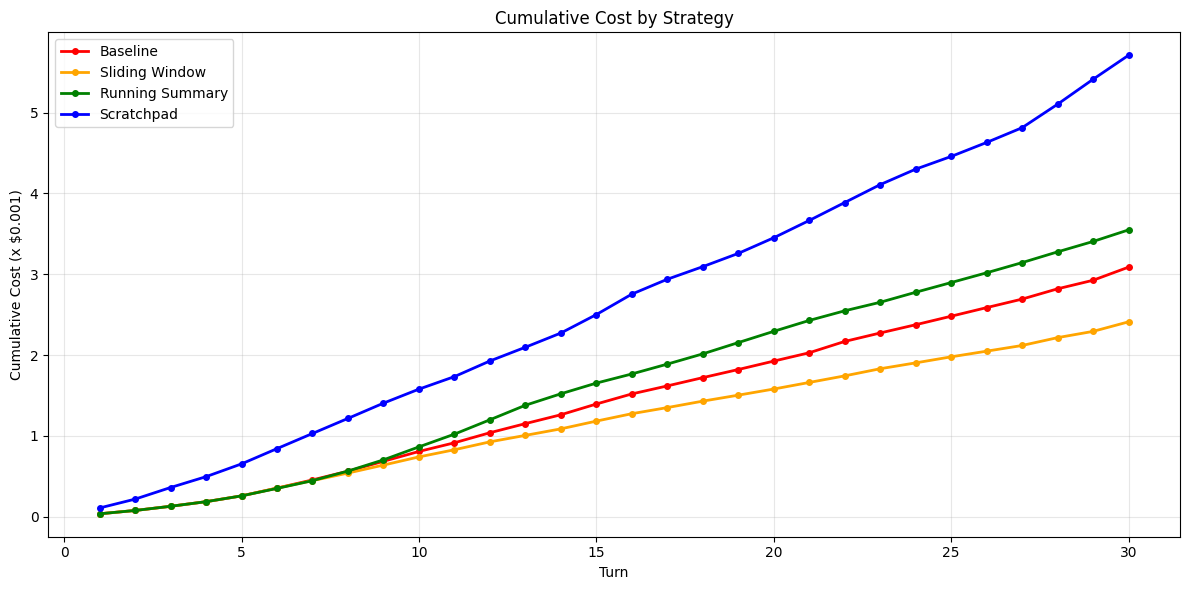

In [33]:
plot_cumulative_cost(strategies, len(TURNS))

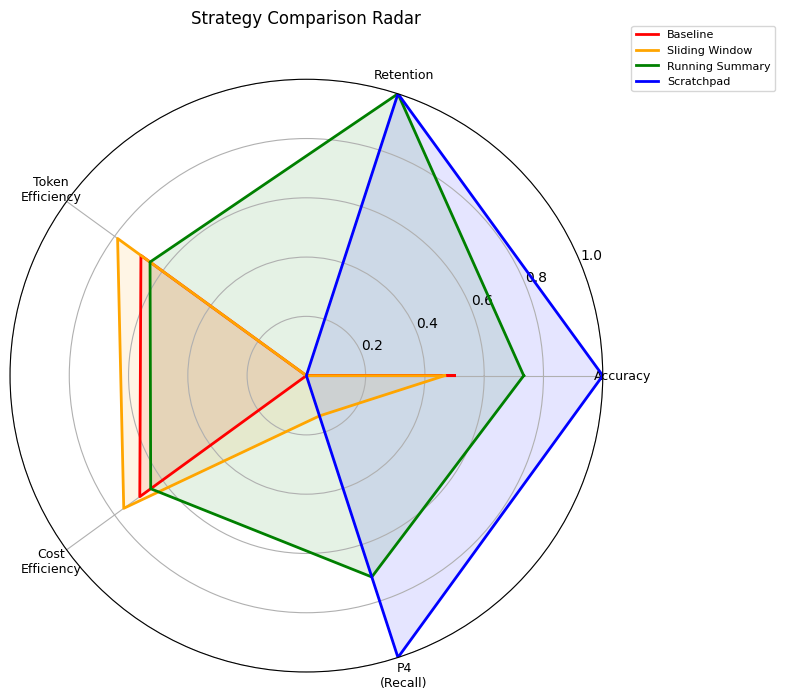

In [34]:
plot_radar(strategies)

## Strategy Reference

| Strategy | Trigger | Action | Knowledge fate | Token growth | What it trades | Failure mode |
|----------|---------|--------|----------------|-------------|----------------|--------------|
| **Baseline** | tokens > budget | Drop oldest messages | Lost permanently | Capped | Old facts | Forgets everything |
| **Sliding Window** | len > WINDOW_SIZE | Keep last N messages | Lost outside window | Capped | Old facts | Forgets everything (faster) |
| **Running Summary** | tokens > 80% budget | Compress old into summary | Lossy compression | Capped | Precision | Facts degrade with each compression |
| **Scratchpad** | len > WINDOW_SIZE | Dump ALL facts to sys_msg | Perfect retention | Linear ↗ | Message budget | Facts survive but conversation space shrinks to zero |